# Class Weighted Model

This notebook trains EfficientNetB2 with class weights to address the severe class imbalance in the ISIC 2019 dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB2
from pathlib import Path
import json
import cv2
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

2026-03-04 16:41:57.151684: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-04 16:41:57.710663: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-04 16:42:09.725178: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
PROJECT_ROOT = Path("../").resolve()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed" / "classification"
ORGANIZED_DIR = DATA_DIR / "organized"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models" / "class_weighted"

MODELS_DIR.mkdir(parents=True, exist_ok=True)

with open(PROJECT_ROOT / "config.json", "r") as f:
    CONFIG = json.load(f)

print(f"Models will be saved to: {MODELS_DIR}")

Models will be saved to: models/class_weighted


## 1. Compute Class Weights

Calculate class weights inversely proportional to class frequency.

Formula: `weight = total_samples / (num_classes * class_samples)`

Class Distribution in Training Set:
class_label
AKIEC     229
BCC       360
BKL       769
DF         81
MEL       779
NV       4693
VASC       99
Name: count, dtype: int64

Total samples: 7010

Class Weights (by class index):
  AKIEC (index 0): 4.3731
  BCC (index 1): 2.7817
  BKL (index 2): 1.3022
  DF (index 3): 12.3633
  MEL (index 4): 1.2855
  NV (index 5): 0.2134
  VASC (index 6): 10.1154


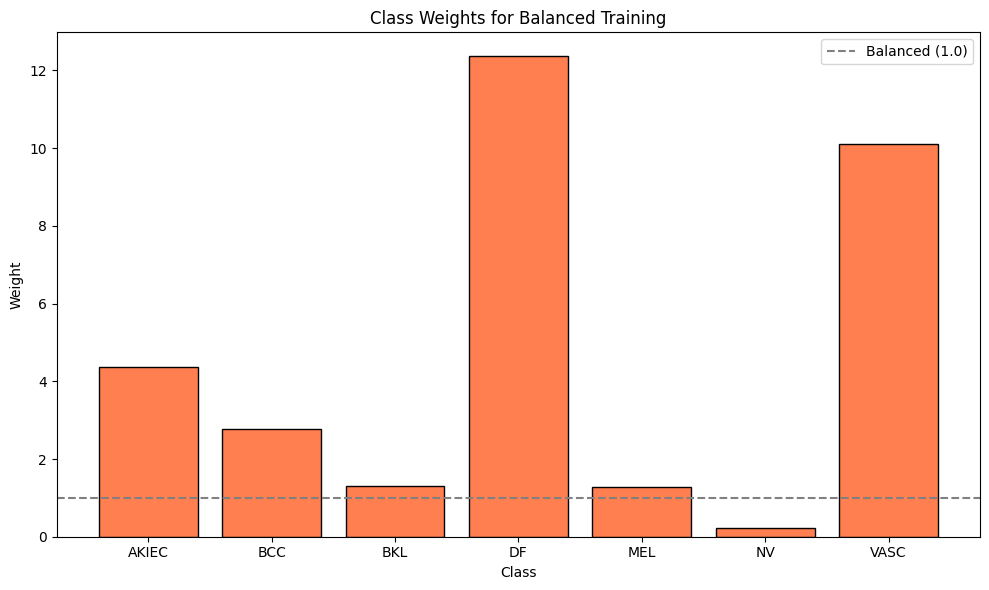

In [4]:
IMG_SIZE = 256
BATCH_SIZE = 64
NUM_CLASSES = 8

CLASS_NAMES = ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']

# Load training labels
train_split_path = DATA_DIR / "train_split.csv"
df_train = pd.read_csv(train_split_path)

# Get class distribution
class_counts = df_train['class_label'].value_counts().sort_index()
print("Class Distribution in Training Set:")
print(class_counts)
print(f"\nTotal samples: {len(df_train)}")

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df_train['class_label']),
    y=df_train['class_label']
)

# Create class weight dictionary
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
class_weight_dict_by_name = {cls: class_weight_dict[i] for i, cls in enumerate(CLASS_NAMES)}

print("\nClass Weights (by class index):")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {cls} (index {i}): {class_weight_dict[i]:.4f}")

# Visualize weights
plt.figure(figsize=(10, 6))
plt.bar(CLASS_NAMES, class_weights, color='coral', edgecolor='black')
plt.axhline(y=1.0, color='gray', linestyle='--', label='Balanced (1.0)')
plt.xlabel('Class')
plt.ylabel('Weight')
plt.title('Class Weights for Balanced Training')
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'class_weights.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Load Data

Load training and validation datasets.

In [5]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

In [6]:
# Load training data
train_dir = ORGANIZED_DIR / "train"

train_ds = keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='int'
)

val_ds = keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='int'
)

# Performance optimization
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    train_ds
    .cache()
    .shuffle(1000)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .cache()
    .prefetch(AUTOTUNE)
)

print(f"Training batches: {len(train_ds)}")
print(f"Validation batches: {len(val_ds)}")

Found 7010 files belonging to 7 classes.
Using 5608 files for training.


I0000 00:00:1772642669.532166  133783 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13685 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 7010 files belonging to 7 classes.
Using 1402 files for validation.
Training batches: 88
Validation batches: 22


## 3. Build Model

Same architecture as baseline.

In [7]:
def build_model():
    """Build EfficientNetB2 model with augmentation."""

    img_augmentation = keras.Sequential(
        [
            layers.RandomRotation(factor=0.15),
            layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
            layers.RandomFlip(),
            layers.RandomContrast(factor=0.1),
        ],
        name="img_augmentation",
    )

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = img_augmentation(inputs)

    base_model = EfficientNetB2(
        include_top=False,
        input_tensor=x,
        weights="imagenet"
    )
    base_model.trainable = False

    x = layers.GlobalAveragePooling2D(name="avg_pool")(base_model.output)
    x = layers.Dropout(0.2, name="top_dropout")(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="pred")(x)

    model = keras.Model(inputs, outputs, name="EfficientNet_ClassWeighted")
    return model, base_model

model, base_model = build_model()
model.summary()

2026-03-04 16:44:35.344523: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


Model: "EfficientNet_ClassWeighted"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_augmentation    │ (None, 256, 256,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 256, 256,  │          0 │ img_augmentation… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 256, 256,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 256, 256,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 257, 257,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 128, 128,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 128, 128,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 128, 128,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 128, 128,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 128, 128,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 128, 128,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 128, 128,  │          0 │ block1a_activati

 Total params: 7,779,841 (29.68 MB)

 Trainable params: 11,272 (44.03 KB)

 Non-trainable params: 7,768,569 (29.63 MB)

## 4. Phase 1: Feature Extraction with Class Weights

Train with frozen base model, using class weights.

In [8]:
# Compile for Phase 1
optimizer = keras.optimizers.Adam(learning_rate=1e-2)
model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(MODELS_DIR / 'phase1_best.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("Phase 1: Feature Extraction with Class Weights")
print(f"Class weights: {class_weight_dict}")

history1 = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

Phase 1: Feature Extraction with Class Weights
Class weights: {0: np.float64(4.37305053025577), 1: np.float64(2.7817460317460316), 2: np.float64(1.3022478172023035), 3: np.float64(12.36331569664903), 4: np.float64(1.285530900421786), 5: np.float64(0.21338772031292808), 6: np.float64(10.115440115440116)}
Epoch 1/20


2026-03-04 16:44:58.571459: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.3395 - loss: 2.0789
Epoch 1: val_accuracy improved from None to 0.41369, saving model to models/class_weighted/phase1_best.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 55s 360ms/step - accuracy: 0.4199 - loss: 1.8407 - val_accuracy: 0.4137 - val_loss: 1.7697 - learning_rate: 0.0100
Epoch 2/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.4890 - loss: 1.4454
Epoch 2: val_accuracy did not improve from 0.41369
88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 219ms/step - accuracy: 0.4971 - loss: 1.4575 - val_accuracy: 0.4023 - val_loss: 2.0751 - learning_rate: 0.0100
Epoch 3/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.5215 - loss: 1.4628
Epoch 3: val_accuracy improved from 0.41369 to 0.53566, saving model to models/class_weighted/phase1_best.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 20s 228ms/step - accuracy: 0.5021 - loss: 1.4534 - val_accuracy: 0.5357 - val_loss: 1.4687 - learning_rate: 0.0100
Epoch 4/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.5573 - loss: 1.3598
Epoch 4: val_accuracy improved from 0.53566 to 0.54351, saving model to models/class_weighted/phase1_best.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 20s 226ms/step - accuracy: 0.5574 - loss: 1.3320 - val_accuracy: 0.5435 - val_loss: 1.4341 - learning_rate: 0.0100
Epoch 5/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.5567 - loss: 1.3883
Epoch 5: val_accuracy improved from 0.54351 to 0.55635, saving model to models/class_weighted/phase1_best.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 20s 227ms/step - accuracy: 0.5553 - loss: 1.3444 - val_accuracy: 0.5563 - val_loss: 1.3286 - learning_rate: 0.0100
Epoch 6/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.5278 - loss: 1.3722
Epoch 6: val_accuracy did not improve from 0.55635
88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 218ms/step - accuracy: 0.5439 - loss: 1.3305 - val_accuracy: 0.3716 - val_loss: 2.2566 - learning_rate: 0.0100
Epoch 7/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.5536 - loss: 1.2895
Epoch 7: val_accuracy did not improve from 0.55635
88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 218ms/step - accuracy: 0.5619 - loss: 1.3204 - val_accuracy: 0.4872 - val_loss: 1.6758 - learning_rate: 0.0100
Epoch 8/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.5363 - loss: 1.4090
Epoch 8: val_accuracy improved from 0.55635 to 0.61698, saving model to models/class_weighted/phase1_best.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 20s 228ms/step - accuracy: 0.5430 - loss: 1.3991 - val_accuracy: 0.6170 - val_loss: 1.2612 - learning_rate: 0.0100
Epoch 9/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.5745 - loss: 1.2190
Epoch 9: val_accuracy did not improve from 0.61698
88/88 ━━━━━━━━━━━━━━━━━━━━ 20s 222ms/step - accuracy: 0.5528 - loss: 1.3288 - val_accuracy: 0.5649 - val_loss: 1.4046 - learning_rate: 0.0100
Epoch 10/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.5402 - loss: 1.2979
Epoch 10: val_accuracy did not improve from 0.61698
88/88 ━━━━━━━━━━━━━━━━━━━━ 21s 224ms/step - accuracy: 0.5389 - loss: 1.4501 - val_accuracy: 0.5699 - val_loss: 1.3668 - learning_rate: 0.0100
Epoch 11/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.5750 - loss: 1.3075
Epoch 11: val_accuracy did not improve from 0.61698
88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 221ms/step - accuracy: 0.5653 - loss: 1.4371 - val_accuracy: 0.5178 - val_loss: 1.7284 - learning_rate: 0.0100
Epoch 12/20
88/88

## 5. Phase 2: Fine-Tuning with Class Weights

Unfreeze all layers and continue training with lower learning rate.

In [9]:
# Unfreeze base model
base_model.trainable = True

# Recompile with lower learning rate
optimizer = keras.optimizers.Adam(learning_rate=1e-4)
model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Update callbacks
callbacks[1] = keras.callbacks.ModelCheckpoint(
    filepath=str(MODELS_DIR / 'final_best.h5'),
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

print("Phase 2: Fine-Tuning with Class Weights")

history2 = model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    initial_epoch=len(history1.history['loss'])
)

Phase 2: Fine-Tuning with Class Weights
Epoch 21/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.5919 - loss: 0.9995
Epoch 21: val_accuracy improved from None to 0.63124, saving model to models/class_weighted/final_best.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 31s 259ms/step - accuracy: 0.6015 - loss: 1.0340 - val_accuracy: 0.6312 - val_loss: 1.1183 - learning_rate: 1.0000e-04
Epoch 22/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.6113 - loss: 1.0533
Epoch 22: val_accuracy did not improve from 0.63124
88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 220ms/step - accuracy: 0.6170 - loss: 1.0834 - val_accuracy: 0.6213 - val_loss: 1.1478 - learning_rate: 1.0000e-04
Epoch 23/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.6161 - loss: 0.9942
Epoch 23: val_accuracy did not improve from 0.63124
88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 220ms/step - accuracy: 0.6173 - loss: 0.9913 - val_accuracy: 0.6205 - val_loss: 1.1475 - learning_rate: 1.0000e-04
Epoch 24/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.6202 - loss: 1.0544
Epoch 24: val_accuracy did not improve from 0.63124
88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 219ms/step - accuracy: 0.6266 - loss: 1.0508 - val_accuracy: 0.6170 - val_loss: 1.1548 - learning_rate: 1.0000e-04

## 6. Save Model and History

Save the trained model and training history.

In [11]:
# Save final model
model.save(MODELS_DIR / 'efficientnet_classweighted_final.h5')
# print(f"Model saved to: {MODELS_DIR / 'efficientnet_classweighted_final.h5'}")

# Save training history
history_combined = {
    'loss': history1.history['loss'] + history2.history['loss'],
    'accuracy': history1.history['accuracy'] + history2.history['accuracy'],
    'val_loss': history1.history['val_loss'] + history2.history['val_loss'],
    'val_accuracy': history1.history['val_accuracy'] + history2.history['val_accuracy']
}

np.save(MODELS_DIR / 'training_history.npy', history_combined)
print("Training history saved.")

# Save class weights
with open(MODELS_DIR / 'class_weights.json', 'w') as f:
    json.dump(class_weight_dict_by_name, f, indent=2)
print("Class weights saved.")

Training history saved.
Class weights saved.


## 7. Training History Visualization

Compare training curves.

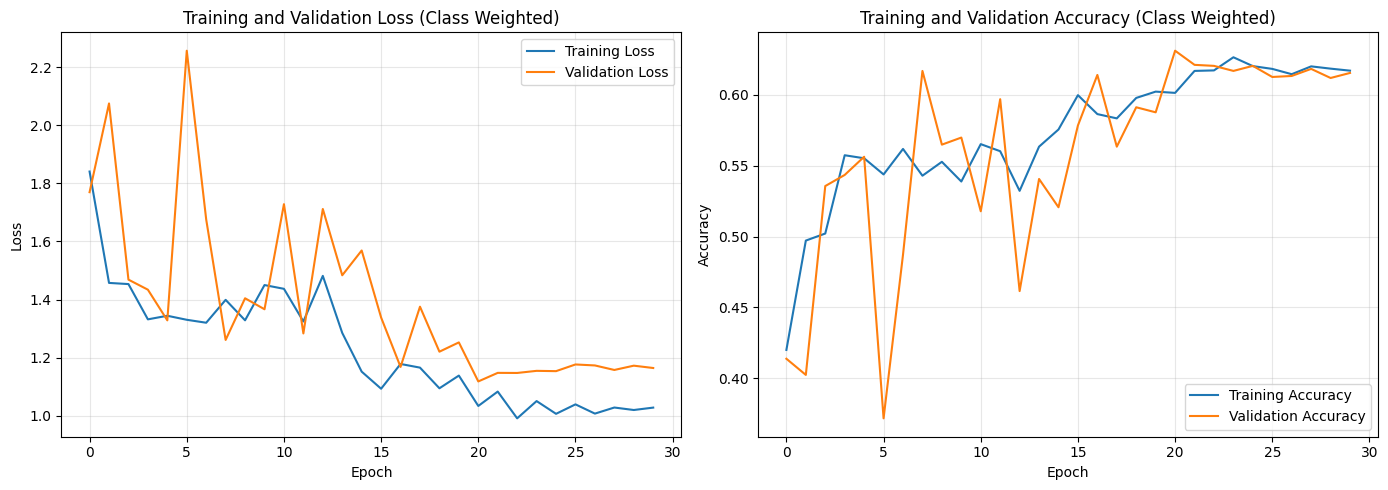

Final Training Accuracy: 0.6172
Final Validation Accuracy: 0.6155


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history_combined['loss'], label='Training Loss')
axes[0].plot(history_combined['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss (Class Weighted)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history_combined['accuracy'], label='Training Accuracy')
axes[1].plot(history_combined['val_accuracy'], label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy (Class Weighted)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'classweighted_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Final Training Accuracy: {history_combined['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_combined['val_accuracy'][-1]:.4f}")

## 8. Test Set Evaluation

Evaluate on held-out test set.

In [13]:
# Load test data
test_dir = ORGANIZED_DIR / "test"

test_ds = keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False
)

# Get predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Classification report
print("Classification Report (Class Weighted):")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

Found 1503 files belonging to 7 classes.
Classification Report (Class Weighted):
              precision    recall  f1-score   support

       AKIEC       0.47      0.33      0.39        49
         BCC       0.53      0.34      0.41        77
         BKL       0.46      0.36      0.41       165
          DF       0.09      0.71      0.16        17
         MEL       0.28      0.49      0.36       167
          NV       0.91      0.71      0.80      1006
        VASC       0.25      0.86      0.39        22

    accuracy                           0.62      1503
   macro avg       0.43      0.54      0.42      1503
weighted avg       0.74      0.62      0.66      1503



2026-03-04 16:56:06.997617: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 9. Confusion Matrix

Visualize prediction patterns.

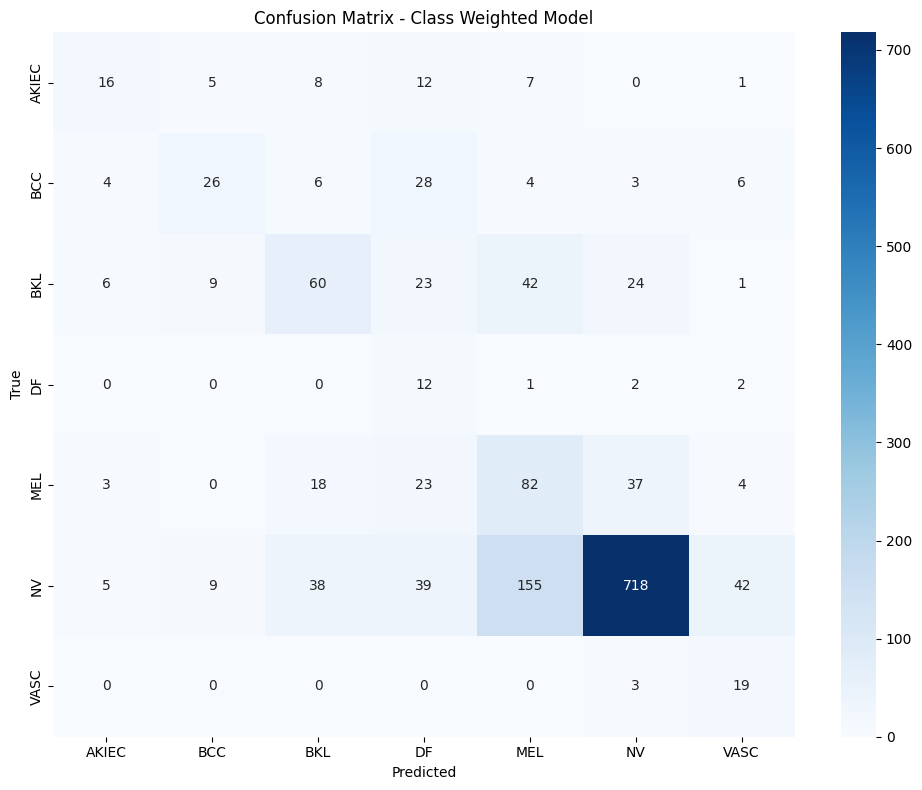

In [14]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Class Weighted Model')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'classweighted_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Per-Class Performance Analysis

Compare performance across classes, especially minority classes.

Per-Class Performance (Class Weighted):
Class  Total_Images  Correct_Predictions  Accuracy  Class_Weight
AKIEC            49                   16  0.326531      4.373051
  BCC            77                   26  0.337662      2.781746
  BKL           165                   60  0.363636      1.302248
   DF            17                   12  0.705882     12.363316
  MEL           167                   82  0.491018      1.285531
   NV          1006                  718  0.713718      0.213388
 VASC            22                   19  0.863636     10.115440


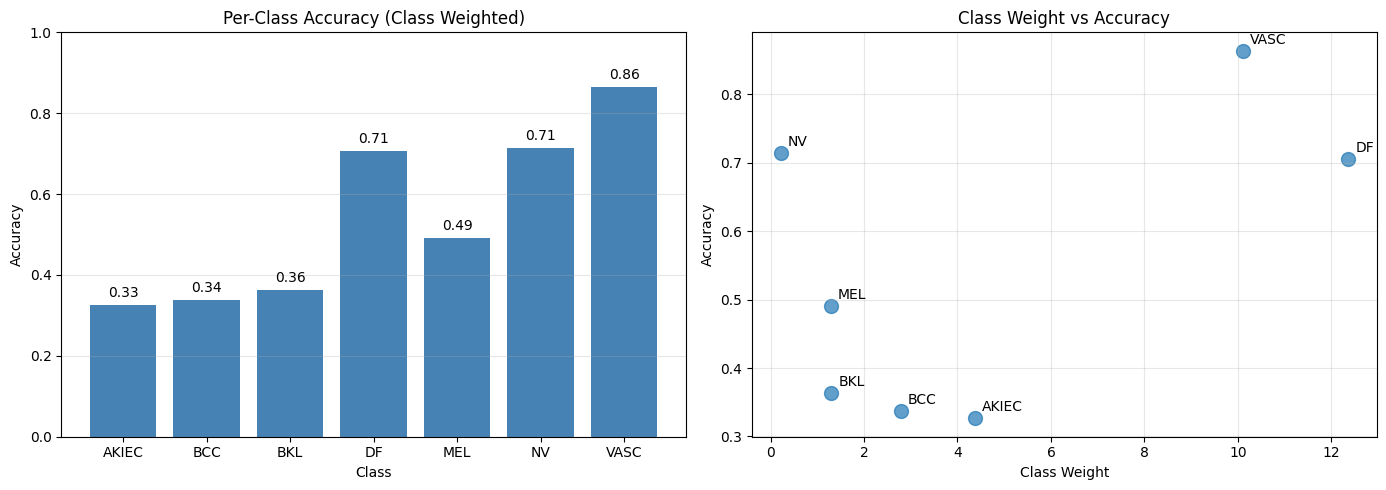


Results saved to: results/classweighted_results.csv


In [15]:
# Calculate per-class accuracy
class_correct = {cls: 0 for cls in CLASS_NAMES}
class_total = {cls: 0 for cls in CLASS_NAMES}

for true, pred in zip(y_true, y_pred):
    true_class = CLASS_NAMES[true]
    pred_class = CLASS_NAMES[pred]

    class_total[true_class] += 1
    if true == pred:
        class_correct[true_class] += 1

# Create results dataframe
results_df = pd.DataFrame({
    'Class': CLASS_NAMES,
    'Total_Images': [class_total[cls] for cls in CLASS_NAMES],
    'Correct_Predictions': [class_correct[cls] for cls in CLASS_NAMES],
    'Accuracy': [class_correct[cls] / class_total[cls] if class_total[cls] > 0 else 0
                 for cls in CLASS_NAMES],
    'Class_Weight': [class_weight_dict_by_name[cls] for cls in CLASS_NAMES]
})

print("Per-Class Performance (Class Weighted):")
print(results_df.to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].bar(results_df['Class'], results_df['Accuracy'], color='steelblue')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Per-Class Accuracy (Class Weighted)')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)
for i, acc in enumerate(results_df['Accuracy']):
    axes[0].text(i, acc + 0.02, f'{acc:.2f}', ha='center')

# Class weights vs accuracy
axes[1].scatter(results_df['Class_Weight'], results_df['Accuracy'], s=100, alpha=0.7)
for i, cls in enumerate(results_df['Class']):
    axes[1].annotate(cls, (results_df['Class_Weight'].iloc[i], results_df['Accuracy'].iloc[i]),
                     xytext=(5, 5), textcoords='offset points')
axes[1].set_xlabel('Class Weight')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Class Weight vs Accuracy')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save results
results_df.to_csv(RESULTS_DIR / 'classweighted_results.csv', index=False)
print(f"\nResults saved to: {RESULTS_DIR / 'classweighted_results.csv'}")

## 11. Comparison with Baseline

Load baseline results and compare.

Comparison: Baseline vs Class Weighted
Class  Baseline_Accuracy  Weighted_Accuracy  Class_Weight  Improvement
AKIEC           0.102041           0.326531      4.373051     0.224490
  BCC           0.207792           0.337662      2.781746     0.129870
  BKL           0.387879           0.363636      1.302248    -0.024242
   DF           0.235294           0.705882     12.363316     0.470588
  MEL           0.299401           0.491018      1.285531     0.191617
   NV           0.949304           0.713718      0.213388    -0.235586
 VASC           0.500000           0.863636     10.115440     0.363636


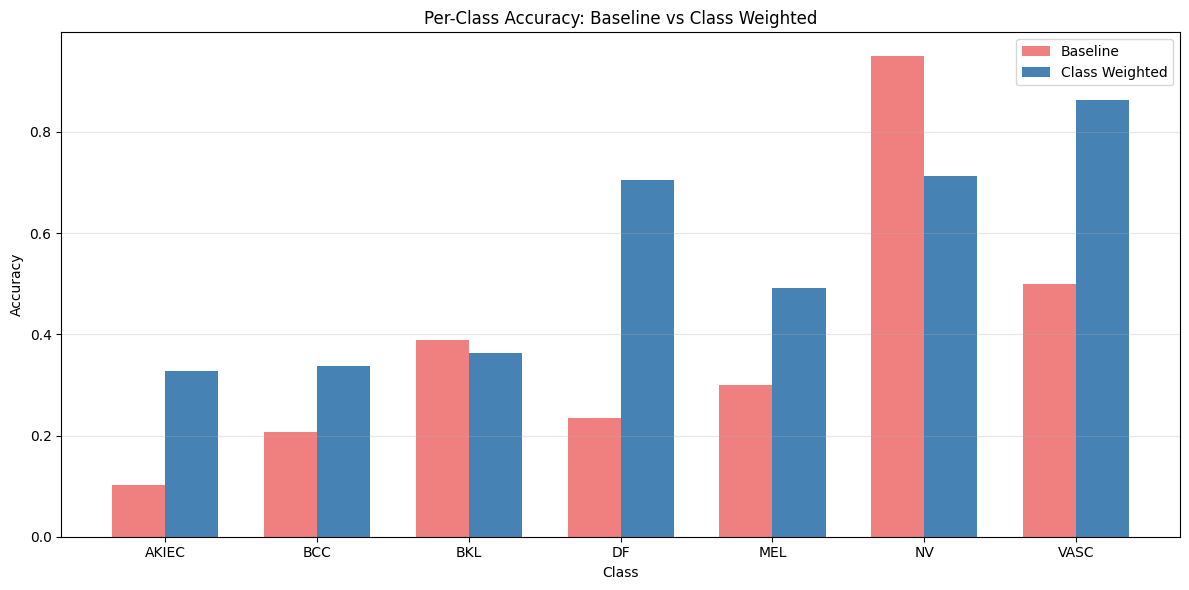


Overall Improvement:
  Mean accuracy improvement: 0.1601
  Minority class improvement (DF, VASC): 0.4171


In [16]:
# Load baseline results if available
baseline_results_path = RESULTS_DIR / 'baseline_results.csv'


baseline_df = pd.read_csv(baseline_results_path)

# Merge results
comparison = pd.merge(
    baseline_df[['Class', 'Accuracy']].rename(columns={'Accuracy': 'Baseline_Accuracy'}),
    results_df[['Class', 'Accuracy', 'Class_Weight']].rename(columns={'Accuracy': 'Weighted_Accuracy'}),
    on='Class'
)
comparison['Improvement'] = comparison['Weighted_Accuracy'] - comparison['Baseline_Accuracy']

print("Comparison: Baseline vs Class Weighted")
print(comparison.to_string(index=False))

# Visualize comparison
x = np.arange(len(CLASS_NAMES))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, comparison['Baseline_Accuracy'], width, label='Baseline', color='lightcoral')
bars2 = ax.bar(x + width/2, comparison['Weighted_Accuracy'], width, label='Class Weighted', color='steelblue')

ax.set_xlabel('Class')
ax.set_ylabel('Accuracy')
ax.set_title('Per-Class Accuracy: Baseline vs Class Weighted')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'baseline_vs_weighted_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print(f"\nOverall Improvement:")
print(f"  Mean accuracy improvement: {comparison['Improvement'].mean():.4f}")
print(f"  Minority class improvement (DF, VASC): {comparison[comparison['Class'].isin(['DF', 'VASC'])]['Improvement'].mean():.4f}")


In [18]:
# Save summary
weighted_summary = {
    'model_type': 'EfficientNetB2',
    'balancing': 'Class Weights',
    'total_epochs': len(history_combined['loss']),
    'final_train_accuracy': float(history_combined['accuracy'][-1]),
    'final_val_accuracy': float(history_combined['val_accuracy'][-1]),
    'class_weights': class_weight_dict_by_name,
    'per_class_accuracy': {
        cls: float(class_correct[cls] / class_total[cls]) if class_total[cls] > 0 else 0
        for cls in CLASS_NAMES
    },
    'class_totals': {cls: int(class_total[cls]) for cls in CLASS_NAMES},
    'class_correct': {cls: int(class_correct[cls]) for cls in CLASS_NAMES}
}

with open(RESULTS_DIR / 'classweighted_summary.json', 'w') as f:
    json.dump(weighted_summary, f, indent=2)